In [1]:
%matplotlib inline
import matplotlib.pyplot as plt 
from matplotlib import gridspec
from sklearn.datasets import make_classification
import numpy as np
# pick the seed for reproducibility - change it to explore the effects of random variations
np.random.seed(0)
import random

In [3]:
n = 100
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0.2)
X = X.astype(np.float32)
Y = Y.astype(np.int32)

# Split into train and test dataset
train_x, test_x = np.split(X, [n*8//10])
train_labels, test_labels = np.split(Y, [n*8//10])

In [4]:
def plot_dataset(suptitle, features, labels):
    # prepare the plot
    fig, ax = plt.subplots(1, 1)
    #pylab.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle, fontsize = 16)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')

    colors = ['r' if l else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    fig.show()

C:\Users\jsand\AppData\Local\Temp\ipykernel_8868\1441799467.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


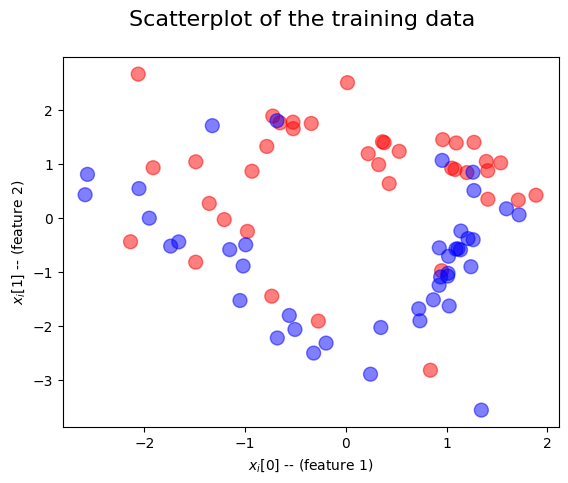

In [5]:
plot_dataset('Scatterplot of the training data', train_x, train_labels)
plt.show()

Loss functions for regression

In [6]:
def plot_loss_functions(suptitle, functions, ylabels, xlabel):
    fig, ax = plt.subplots(1,len(functions), figsize=(9, 3))
    plt.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle)
    for i, fun in enumerate(functions):
        ax[i].set_xlabel(xlabel)
        if len(ylabels) > i:
            ax[i].set_ylabel(ylabels[i])
        ax[i].plot(x, fun)
    plt.show()

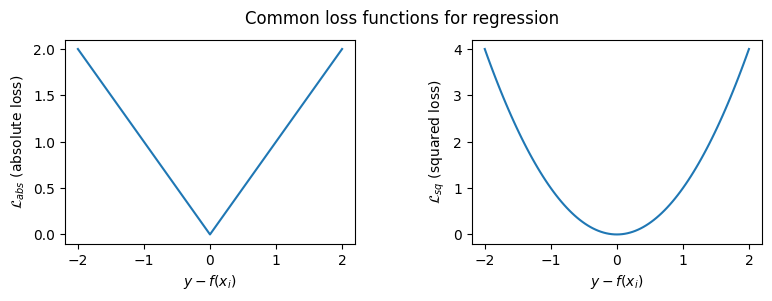

In [7]:
x = np.linspace(-2, 2, 101)
plot_loss_functions(
    'Common loss functions for regression',
    [np.abs(x), np.power(x, 2)],
    ['$\mathcal{L}_{abs}$ (absolute loss)', '$\mathcal{L}_{sq}$ (squared loss)'],
    '$y - f(x_i)$'
)

Loss functions for classification

In [8]:
x = np.linspace(0,1,100)
def zero_one(d):
    if d < 0.5:
        return 0
    return 1
zero_one_v = np.vectorize(zero_one)

def logistic_loss(fx):
    # assumes y == 1
    return -np.log(fx)

C:\Users\jsand\AppData\Local\Temp\ipykernel_8868\331859503.py:10: RuntimeWarning: divide by zero encountered in log
  return -np.log(fx)


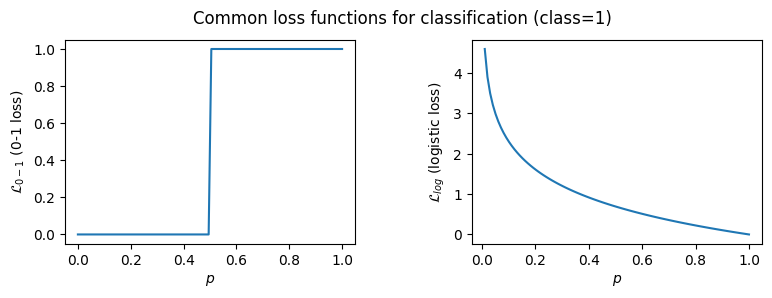

In [9]:
plot_loss_functions(
    'Common loss functions for classification (class=1)',
    [zero_one_v(x), logistic_loss(x)],
    ['$\mathcal{L}_{0-1}$ (0-1 loss)', '$\mathcal{L}_{log}$ (logistic loss)'],
    '$p$'
)

Neural Network Architecture

In [20]:
class Linear:
    def __init__(self,nin,nout):
        self.W = np.random.normal(0, 1.0/np.sqrt(nin), (nout, nin))
        self.b = np.zeros((1,nout))
        
    def forward(self, x):
        return np.dot(x, self.W.T) + self.b
    
net = Linear(2,2)
net.forward(train_x[0:5])

array([[-1.24710023, -0.22912098],
       [-0.80388511, -0.1472087 ],
       [ 0.87240338, -0.02850515],
       [ 1.51494745,  0.06252421],
       [ 1.19076388,  0.09542798]])

In [21]:
class Softmax:
    def forward(self,z):
        zmax = z.max(axis=1,keepdims=True)
        expz = np.exp(z-zmax)
        Z = expz.sum(axis=1,keepdims=True)
        return expz / Z

softmax = Softmax()
softmax.forward(net.forward(train_x[0:10]))

array([[0.2654212 , 0.7345788 ],
       [0.3414866 , 0.6585134 ],
       [0.71113617, 0.28886383],
       [0.81037109, 0.18962891],
       [0.74938517, 0.25061483],
       [0.20320591, 0.79679409],
       [0.13893509, 0.86106491],
       [0.58208329, 0.41791671],
       [0.63756584, 0.36243416],
       [0.14033693, 0.85966307]])

In [22]:
def plot_cross_ent():
    p = np.linspace(0.01, 0.99, 101) # estimated probability p(y|x)
    cross_ent_v = np.vectorize(cross_ent)
    f3, ax = plt.subplots(1,1, figsize=(8, 3))
    l1, = plt.plot(p, cross_ent_v(p, 1), 'r--')
    l2, = plt.plot(p, cross_ent_v(p, 0), 'r-')
    plt.legend([l1, l2], ['$y = 1$', '$y = 0$'], loc = 'upper center', ncol = 2)
    plt.xlabel('$\hat{p}(y|x)$', size=18)
    plt.ylabel('$\mathcal{L}_{CE}$', size=18)
    plt.show()

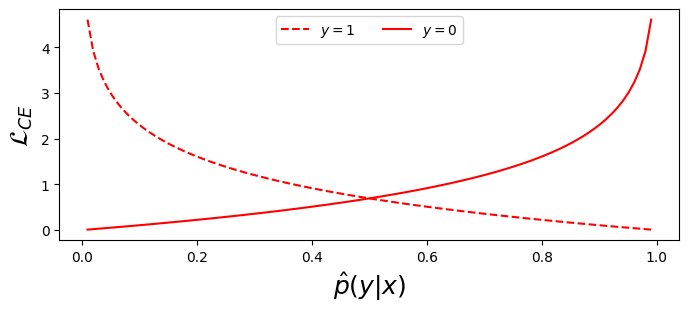

In [23]:
def cross_ent(prediction, ground_truth):
    t = 1 if ground_truth > 0.5 else 0
    return -t * np.log(prediction) - (1 - t) * np.log(1 - prediction)
plot_cross_ent()

In [24]:
class CrossEntropyLoss:
    def forward(self,p,y):
        self.p = p
        self.y = y
        p_of_y = p[np.arange(len(y)), y]
        log_prob = np.log(p_of_y)
        return -log_prob.mean() # average over all input samples

cross_ent_loss = CrossEntropyLoss()
p = softmax.forward(net.forward(train_x[0:10]))
cross_ent_loss.forward(p,train_labels[0:10])

1.0541848443525057